In this notebook are is the code for creating the graphs put in the thesis for chapters 4 and 5.

In [1]:
# CIL imports
from cil.framework import ImageGeometry, AcquisitionGeometry, BlockDataContainer, ImageData

# From cil.plugins import TomoPhantom
from phantominator import shepp_logan

from cil.optimisation.algorithms import FISTA

from cil.plugins.ccpi_regularisation.functions import FGP_TV

from cil.optimisation.functions import LeastSquares, BlockFunction, L2NormSquared, IndicatorBox
from cil.optimisation.utilities import callbacks

# For display
from cil.utilities.display import show2D, show1D, show_geometry

# ASTRA imports
from cil.plugins.astra.operators import ProjectionOperator

from cil.optimisation.algorithms import CGLS, GD

# External imports
import numpy as np
import matplotlib.pyplot as plt
import logging

from cil.optimisation.operators import BlockOperator, DiagonalOperator, GradientOperator, \
                                        CompositionOperator, ZeroOperator, MaskOperator

import time

## Functions 

In [40]:
def mean_RTR(R, n_pixels):
    """
    R is a ProjectionOperator
    """
    two_norm = L2NormSquared()
    get_ig = R.domain_geometry()

    sum = 0
    for k in range(3):

        # generate random entries
        xk = np.random.normal(0, 1, (n_pixels, n_pixels))

        # put random entries in class <DataContainer>
        xk_datacon = get_ig.allocate()
        xk_datacon.fill(xk)

        # compute 
        yk = R.direct(xk_datacon)
        sum += two_norm(yk)
    
    final = (1/3)*sum
    final_mean = (1/(n_pixels**2)) * final
    return final_mean

def create_abs(weights, n, RTRI_mean, alpha, vox_size):
    """
    Creates the entries of the matrix in figure (41) in the article 'Fast Iteratively Reweighted Least Squares
    Algorithms for Analysis-Based Sparsity Reconstruction'

    INPUT
        n: number of pixels (n_pixels)
        A: ProjectionOperator
        weights: weights in np.array(), not flattened

    OUTPUT
        a: diagonal elements of figure (41)
        b: lower- and upperdiagonal elements of figure (41)
        c: offdiagonal elements of figure (41)
    """

    weights_arr = weights.as_array()
    w = weights_arr.flatten()
    N_big = n**2

    a = np.zeros(N_big)
    b = np.zeros(N_big - 1)

    for i in range(n):
        k = i * n

        # first n entries
        if i == 0:
            a[k: k + n] = w[k: k + n]
            a[k: k + n - 1] += w[k: k + n - 1]
            a[k + 1: k + n] += w[k: k + n - 1]
            b[k: k + n - 1] = -w[k: k + n - 1]

        # last n entries
        elif i == n-1:
            a[k: k + n] = w[k - n: k]
            a[k: k + n - 1] += w[k: k + n - 1]
            a[k + 1: k + n] += w[k: k + n - 1]
            b[k: k + n - 1] = -w[k: k + n - 1]

        # middle N-2n entries
        else:
            a[k: k + n] = w[k: k + n] + w[k - n: k]
            a[k: k + n - 1] += w[k: k + n - 1]
            a[k + 1: k + n] += w[k: k + n - 1]
            b[k: k + n - 1] = -w[k: k + n - 1]

    mult_fac = alpha * ((1 / vox_size) ** 2) 

    a_final = mult_fac * a + RTRI_mean

    # creating offdiagonal elements
    c = (-weights_arr.flatten())[:N_big - n]
    
    b *= mult_fac
    c *= mult_fac

    return a_final, b, c

def solve_Ux(diag, updiag, offdiag, input):
    """

    Solves Ux = input, if the matrix U is upper triangular and 
    has the form as in figure (43)
    
    INPUT:
        diag: diagonal elements of U (np.array())
        updiag: upper diagonal elements of U (np.array())
        offdiag: off diagonal elements of U (np.array())
        input: known vector (np.array())

    OUTPUT:
        x: solution to Ux = input (np.array())

    """

    # relation between N and n is given in the article
    N_big = len(diag)
    n = int(np.sqrt(N_big))

    x = np.zeros(N_big)
    x[-1] = input[-1] / diag[-1]    

    # loop over entries of x, first element last
    for i in range(2, N_big + 1):   
        k = N_big - i
        
        # if statements since only part of the entries of x are affected by offdiagonal entries
        if k >= N_big - n:   
            #print("first if", N_big - i)
            x[k] = (1 / diag[k]) * (input[k] - updiag[k]*x[k + 1])
        if k < N_big - n:
            #print("second if", N_big - i)
            x[k] = (1 / diag[k]) * (input[k] - updiag[k]*x[k + 1] - offdiag[k] * x[k + n])

    return x

def solve_Lx(lowdiag, offdiag, input):

    """ 
    solves Lx = input, with L lower triangular and in the from of figure (42)

    INPUT:
        lowdiag: lower diagonal entries (np.array())
        offdiag: offdiagonal entries (np.array())
        input: known vector (np.array())

    OUTPUT:
        x: solution to Lx = y (np.array())
    """
    
    # relation between N and n is given in the article
    N_big = len(input)
    n = int(np.sqrt(N_big))

    x = np.zeros(N_big)
    x[0] = input[0]

    # loop over the entries of x
    for i in range(1, N_big):

        # if statements, since the offdiagonal entries only influence part of x
        if i < n:
            x[i] = input[i] - lowdiag[i - 1]*x[i - 1]
        if i >= n:
            x[i] = input[i] - lowdiag[i - 1]*x[i - 1] - offdiag[i - n]*x[i - n]

    return x

def solve_Pxy(P_a, P_b, P_c, input):
    
    """
    solves Px = input, with P the matrix as in figure (41) of the article 
    'Fast Iteratively Reweighted Least Squares Algorithms for Analysis-Based 
    Sparsity Reconstruction'. P has an known incomplete LU decomposition. 

    INPUT:
        P_a: diagonal elements of the matrix in figure (41) (np.array())
        P_b: lower- and upperdiagonal elements of the matrix in figure (41) (np.array())
        P_c: offdiagonal elements of the matrix in figure (41) (np.array())
        input: known in Px = input (ImageData)
    
    OUTPUT:
        x: solution of Px = input (ImageData) 
    """

    L_lowdiag = P_b / P_a[:-1]
    L_offdiag = P_c / P_a[:len(P_c)]

    sol = input.copy()
    
    input_arr = input.as_array()
    n = len(input_arr)
    input_flat = input_arr.flatten()

    temp_solve = solve_Lx(L_lowdiag, L_offdiag, input_flat)
    x = solve_Ux(P_a, P_b, P_c, temp_solve)
    
    x_reshape = np.reshape(x, (n, n))
    sol.fill(x_reshape)

    return sol


In [3]:
# functions to set A, ig, ag, phantom, etc.

def get_A(n_angles, n_pixels):

    # Angles
    angles = np.linspace(0, 180, n_angles, endpoint=False, dtype=np.float32)

    # Setup acquisition geometry
    ag = AcquisitionGeometry.create_Parallel2D()\
                                .set_angles(angles)\
                                .set_panel(n_pixels, pixel_size=1/n_pixels)

    # Setup image geometry
    ig = ImageGeometry(voxel_num_x=n_pixels, 
                    voxel_num_y=n_pixels, 
                    voxel_size_x=1/n_pixels, 
                    voxel_size_y=1/n_pixels)
    
    A = ProjectionOperator(ig, ag, device='cpu')

    # Get phantom
    phantom = ImageData(np.flip(shepp_logan(n_pixels)), geometry = ig)

    # Create an acquisition data (numerically)
    sino = A.direct(phantom)

    return A, sino, ig, ag, phantom

def add_poss_noise(background_counts, n_angles, n_pixels):
    A, sino, ig, ag, phantom = get_A(n_angles, n_pixels)

    # adding noise to the sinogram, lower background counts makes for more noise

    # Convert the simulated absorption sinogram to transmission values using Lambert-Beer. 
    counts_poss = background_counts * np.exp(-sino.as_array())

    # Use as a mean for Poisson data generation.
    noisy_counts_poss = np.random.poisson(counts_poss)
    nonzero = noisy_counts_poss > 0

    # Convert back to absorption sinogram.
    sino_out_poss = np.zeros_like(sino.as_array())
    sino_out_poss[nonzero] = -np.log(noisy_counts_poss[nonzero]/ background_counts)

    # allocate sino_noisy and fill with noisy data
    sino_noisy_poss = ag.allocate()
    sino_noisy_poss.fill(sino_out_poss)

    return sino_noisy_poss

In [12]:
def lasso_cgls(initial, inner_iter, outer_iter, R, sino, alpha, er, cg_tol, exact):

    """
    Function that minimises the cost function 

    J(u) = ||Ru - y||_2^2 + alpha ||u||_1

    by minimising 

    J(u) = ||Ru - y||_2^2 + alpha ||W_k u||_2^2

    via the BlockFramework and the cgls function from CIL. the matrix W_k is reweighted in each iteration
    with W_k = u_k**(-1/2)

    Input
        Initial:    initial guess for u (ImageData)
        inner_iter: maximum number of iterations for cgls (integer)
        outer_iter: maximum number of iterations to reweight W_k (integer)
        R:          operator R (ProjectionOperator)
        sino:       lhs of the data fidelity term, 'y' (ImageData)
        alpha:      regularisation parameter (float)
        er:         lower bound for values in W_k to be considered to reweight, 
                    low values will be set to zero (float)
        cg_tol:     tolerance for cg (float)
        exact:      if known, the exact solution to the reconstruction problem (ImageData), 
                    if not known, put None and the backward error is computed

    Output
        uk:         reconstructed image (ImageData)
        err:        backward error or forward error depending on what is inputted in 'exact' (numpy array)
    """

    uk = initial.copy()
    get_ig = R.domain_geometry()

    if er is None:
        er_use = 0.01 * sino.max()
    else:
        er_use = er

    err = []
    norm = L2NormSquared()
    norm_b = norm(sino)

    if exact == None:
        err_temp = norm(R.direct(uk) - sino) / norm_b
        err.append(err_temp)
    else:
        err_temp = norm(uk - exact)
        err.append(err_temp)

    for k in range(outer_iter):

        print("Outer iteration:", k + 1)
        
        ## reweight the regularisation term ##
        
        uk_grad = uk.abs()
        uk_grad_np = uk_grad.as_array()

        # distinguish 'large' values from 'small' values
        large_values = uk_grad > er_use # ImageData boolean array

        # reweight large values
        uk_reweighted_np = np.zeros_like(uk.as_array()) # small terms are automatically put to zero
        uk_reweighted_np[large_values] = 2**(1/2)*(uk_grad_np[large_values] ** (-1/2))

        # convert back to ImageData
        uk_reweighted = get_ig.allocate()   
        uk_reweighted.fill(uk_reweighted_np)

        ## setting up minimisation functional in BlockFramework ##

        # set W
        w_operator = DiagonalOperator(uk_reweighted)

        # create block operator
        operator_block = BlockOperator(R, np.sqrt(alpha)*w_operator)

        # create block data container
        zero_block = w_operator.range.allocate(0)
        data_block = BlockDataContainer(sino, zero_block)

        # solver inner minimization problem 
        cgls = CGLS(initial=uk, operator=operator_block, data=data_block, update_objective_interval=1)

        # CGLS EarlyStopping terminates CG when ||..._k|| < epsilon*||..._0||
        cgls.run(inner_iter, verbose=0, callbacks=[callbacks.ProgressCallback(), 
                                                   callbacks.CGLSEarlyStopping(epsilon=cg_tol)])
        uk = cgls.solution
        Ruk_min_sino = R.direct(uk) - sino

        if exact == None:
            err_temp = norm(Ruk_min_sino) / norm_b
            err.append(err_temp)
        else:
            err_temp = norm(uk - exact)
            err.append(err_temp)

        if er is None:
            e = (Ruk_min_sino).abs()
            er_use = 0.01 * e.max()
        else:
            er_use = er

    return uk, err

def tv_cgls(initial, inner_iter, outer_iter, R, sino, alpha, er, cg_tol, exact):

    """
    Function that minimises the cost function 

    J(u) = ||Ru - y||_2^2 + alpha TV(u)

    by minimising 

    J(u) = ||Ru - y||_2^2 + alpha ||tilde{W}_k Du||_2^2

    via the BlockFramework and the cgls function from CIL. The matrix W_k is reweighted in each iteration, and, 

    tilde{W}_k = [[W_k, 0], 
                  [0, W_k]]

    Input
        Initial:    initial guess for u (ImageData)
        inner_iter: maximum number of iterations for cgls (integer)
        outer_iter: maximum number of iterations to reweight W_k (integer)
        R:          operator R (ProjectionOperator)
        sino:       lhs of the data fidelity term, 'y' (ImageData)
        alpha:      regularisation parameter (float)
        er:         lower bound for values in W_k to be considered to reweight, 
                    low values will be set to zero (float)
        cg_tol:     tolerance for cg (float)
        exact:      if known, the exact solution to the reconstruction problem (ImageData), 
                    if not known, put None and the backward error is computed

    Output
        uk:         reconstructed image (ImageData)
        err:        backward error or forward error depending on what is inputted in 'exact' (numpy array)
    
    """

    uk = initial.copy()

    # functions that don't depend on iteration for reweighting regularisation term
    get_ig = R.domain_geometry()
    gradient_operator = GradientOperator(get_ig)   # function that computes D_x, D_y

    norm = L2NormSquared()
    norm_b = norm(sino)
    err = []

    if exact == None:
        err_temp = norm(R.direct(uk) - sino) / norm_b
        err.append(err_temp)
    else:
        err_temp = norm(uk - exact)
        err.append(err_temp)

    if er is None:
        er_use = 0.01 * sino.max()
    else:
        er_use = er

    for k in range(outer_iter):
        
        # creating the weights matrix W^{1/2}
        grad = gradient_operator.direct(uk)
        uk_grad = grad[0]**2 + grad[1]**2
        uk_grad_np = uk_grad.as_array()

        # distinguish 'large' values from 'small' values
        large_values = uk_grad > er_use # ImageData boolean array

        # reweight large values
        uk_reweighted_np = np.zeros_like(uk.as_array()) # small terms are automatically put to zero
        uk_reweighted_np[large_values] = 2**(1/2)*(uk_grad_np[large_values] ** (-1/4))

        # convert back to ImageData
        uk_reweighted = get_ig.allocate()   
        uk_reweighted.fill(uk_reweighted_np)

        W_diagonal = DiagonalOperator(uk_reweighted)

        # creating zero operator blocks
        zero_operator = ZeroOperator(get_ig)

        # reg_operator = [W^{1/2}D_x W^{1/2}D_y]^T
        w_matrix = BlockOperator(W_diagonal, zero_operator, zero_operator, W_diagonal, shape=(2,2))
        reg_operator = CompositionOperator(w_matrix, gradient_operator)

        # create block operator
        operator_block = BlockOperator(R, np.sqrt(alpha)*reg_operator)

        # create block data container
        zero_block = reg_operator.range.allocate(0)
        data_block = BlockDataContainer(sino, zero_block)

        # solver inner minimization problem 
        cgls = CGLS(initial=uk, operator=operator_block, data=data_block, update_objective_interval=1)

        cgls.run(inner_iter, verbose=0, callbacks=[callbacks.CGLSEarlyStopping(cg_tol)])

        uk = cgls.solution

        Ruk_min_sino = R.direct(uk) - sino

        if exact == None:
            err_temp = norm(Ruk_min_sino) / norm_b
            err.append(err_temp)
        else:
            err_temp = norm(uk - exact)
            err.append(err_temp)

        if er is None:
            e = (Ruk_min_sino).abs()
            er_use = 0.01 * e.max()
        else:
            er_use = er

    return uk, err

# CG algorithm
def CG(initial, max_iter, R, RTy, alpha, Wk, cg_tol, apply_operator):

    """
    Solves for u in the system 

    apply_operator(u) = R^Ty (*)

    using Conjugate Gradient (CG)

    INPUT:
        initial:    Inital guess for u (ImageData)
        max_iter:   Maximum number of cg iterations (float)
        R:          ProjectionOperator necessary for 'apply_operator' function
        RTb:        R^Tb (ImageData)
        alpha:      Regularisation parameter (float)
        Wk:         Weights in the kth iteration, necessary for `apply_operator' function (ImageData)
        cg_tol:     Tolerance on CG (float)
        apply_operator: Function that applies matrix from normal equation
    
    OUTPUT:
        uj:         Minimiser of (*) (ImageData)
        conv_arr:   Array with residuals from each iteration (numpy array)
        inner_iter_count:   Number of inner iterations used (float)
    """

    u0 = initial.copy()
    r0 = RTy - apply_operator(x=u0, W=Wk, R=R, alpha=alpha)
    p0 = r0
    
    # set initials, note these are all of class <ImageData> 
    pj = p0
    uj = u0
    rj = r0
    delta_new = rj.dot(rj.conjugate())

    # needed for stopping criteria later
    norm = L2NormSquared()
    r0_norm = norm(r0)
    rel_tol = r0_norm * cg_tol

    # to check convergence
    conv_arr = []
    conv_arr.append(r0_norm)

    # counting inner iterations
    inner_iter_count = max_iter

    # perform CG iterations
    for j in range(max_iter):

        # zk = Rpk
        zj = apply_operator(x=pj, W=Wk, R=R, alpha=alpha)

        tau_j = delta_new/(pj.dot(zj.conjugate()))
        
        uj_plus_one = uj + tau_j * pj 
        rj_plus_one = rj - tau_j * zj

        delta_old = delta_new
        delta_new = rj_plus_one.dot(rj_plus_one.conjugate())

        beta_j = delta_new/delta_old

        pj_plus_one = rj_plus_one + beta_j * pj

        # stopping criteria
        check = norm(rj_plus_one)
        conv_arr.append(check)
        if check < rel_tol:
            uj = uj_plus_one
            inner_iter_count = j + 1
            print(f"cg converged in {j+1} iterations")
            break

        # reset variables
        rj = rj_plus_one
        pj = pj_plus_one
        uj = uj_plus_one

    return uj, conv_arr, inner_iter_count

def apply_operator_lasso(x, W, R, alpha):

    """
    Applies the operator 
    
    R^TR + alpha * W 
    
    to the input ImageData x. Used to solve the normal equations 

    (R^TR + alpha * W_k)u = R^Ty

    with W_k = u_k**(-1)

    Input:
        x:  ImageData to which the operator is applied
        W:  Weights
        alpha:  regularisation parameter

    Output:
        z: ImageData (R^TR + alpha * W)x
    """
    
    # z2 = (R^TR)x
    z1 = R.direct(x)
    z2 = R.adjoint(z1)

    # z3 = Wx
    w_operator = DiagonalOperator(W)
    z3 = w_operator.direct(x)

    z = z2 + alpha * z3

    return z

def lasso_normal(initial, inner_iter, outer_iter, R, sino, alpha, er, cg_tol, exact):
    """
    Finds a solution for the problem 

    ||Ru - y||_2^2 + alpha * ||u||_1

    by first rewriting the regularisation term into a two norm by a weights matrix W and then solving via
    the normal equations using CG. The normal equations are given by 

    (R^TR + alpha*W_k)u = R^Ty

    In each outer iterations the matrix W_k is updated (reweighted), W_k = u_k^(-1)

    Input:
        initial:    Initial guess for u (ImageData)
        inner_iter: Number of CG iterations (scalar)
        outer_iter: Number of outer iterations (scalar)
        R:          The acting operator (Operator)
        sino:       The obtained data (AcquisitionData)
        alpha:      Regularization parameter (scalar)
        er:         Upper bound for 'small values' in W_k that will be set to zero (float)

    Output:
        uk:         Reconstructed image (ImageData)
    """

    # setting up LHS of normal equation
    lhs = R.adjoint(sino)

    # setting initials
    uk = initial.copy()
    get_ig = R.domain_geometry()

    norm = L2NormSquared()
    norm_b = norm(sino)
    err = []

    inner_itercount_arr = []

    if exact == None:
        err_temp = norm(R.direct(uk) - sino) / norm_b
        err.append(err_temp)
    else:
        err_temp = norm(uk - exact)
        err.append(err_temp)

    if er is None:
        er_use = 0.01 * sino.max()
    else:
        er_use = er

    for k in range(outer_iter):

        print(f"outer iteration: {k+1}")
        
        ## reweight the regularisation term ##
        uk_grad = uk.abs()
        uk_grad_np = uk_grad.as_array()

        # distinguish 'large' values from 'small' values
        large_values = uk_grad > er_use # ImageData boolean array

        # reweight large values
        uk_reweighted_np = np.zeros_like(uk.as_array()) # small terms are automatically put to zero
        uk_reweighted_np[large_values] = 2*(uk_grad_np[large_values] ** (-1))

        # convert back to ImageData
        uk_reweighted = get_ig.allocate()   
        uk_reweighted.fill(uk_reweighted_np)

        # performing CG
        cg_output, conv_arr, inner_iter_count = CG(uk, inner_iter, R, lhs, alpha, uk_reweighted, cg_tol, apply_operator_lasso)
        inner_itercount_arr.append(inner_iter_count)

        uk = cg_output
        Ruk_min_sino = R.direct(uk) - sino

        if exact == None:
            err_temp = norm(Ruk_min_sino) / norm_b
            err.append(err_temp)
        else:
            err_temp = norm(uk - exact)
            err.append(err_temp)

        if er is None:
            e = (Ruk_min_sino).abs()
            er_use = 0.01 * e.max()
        else:
            er_use = er

    return uk, err, conv_arr, inner_itercount_arr

## TV regularisation
def apply_operator_tv(x, W, R, alpha):
    
    """
    Applies the operator 
    
    R^TR + alpha *D^T*W_b*D
    
    to the input ImageData x. Used to solve the normal equations 

    (R^TR + alpha * D^T*W_b*D)u = R^Ty

    with W_b = [[W 0],
                [0, W]]
                      
    and W = diag{weights_k}

    Input:
        x:  ImageData to which the operator is applied
        W:  Weights for in W
        R:  Projection operator
        alpha:  regularisation parameter

    Output:
        z: ImageData (R^TR + alpha * D^T*W_b*D)x
    """

    get_ig = R.domain_geometry()
    grad_operator = GradientOperator(get_ig)
    diagonal_weights = DiagonalOperator(W)

    # z1 = Dx
    z1 = grad_operator.direct(x)

    # z2 = Wtilde z1
    z2_a = diagonal_weights.direct(z1[0])
    z2_b = diagonal_weights.direct(z1[1])
    z2 = BlockDataContainer(z2_a, z2_b)

    #z3 = D^T z2 = D^T*Wtilde*Dx
    z3 = grad_operator.adjoint(z2)

    # y2 = R^TRx
    y1 = R.direct(x)
    y2 = R.adjoint(y1)

    final = y2 + alpha * z3

    return final


# CG preconditioned
def CG_tv_preconditioned(initial, max_iter, R, RTy, alpha, Wk, cg_tol, RTRI_mean, vox_size):

    """
    Solves for u in the system 

    (A^TA + alpha * D^TW_bD)u = A^Tb

    using CG

    preconditioned

    """

    u0 = initial.copy()
    r0 = RTy - apply_operator_tv(u0, Wk, R, alpha)

    n_pixels = int(np.sqrt(np.size(u0)))
    P_a, P_b, P_c = create_abs(Wk, n_pixels, RTRI_mean, alpha, vox_size)
    w0 = solve_Pxy(P_a, P_b, P_c, r0)
    p0 = w0

    # set initials, note these are all of class <ImageData>
    wj = w0
    pj = p0
    uj = u0
    rj = r0

    delta_new = rj.dot(wj.conjugate())

    # needed for stopping criteria later
    norm = L2NormSquared()
    r0_norm = norm(r0)
    rel_tol = cg_tol * r0_norm

    # to check convergence
    conv_arr = []
    conv_arr.append(r0_norm)

    # counting inner iterations
    inner_iter_count = max_iter

    # perform CG iterations
    for j in range(max_iter):

        zj = apply_operator_tv(pj, Wk, R, alpha)

        tau_j = delta_new / (pj.dot(zj.conjugate()))

        uj_plus_one = uj + tau_j * pj
        rj_plus_one = rj - tau_j * zj

        delta_old = delta_new
        wj_plus_one = solve_Pxy(P_a, P_b, P_c, rj_plus_one)
        delta_new = wj_plus_one.dot(rj_plus_one.conjugate())

        beta_j = delta_new / delta_old

        pj_plus_one = wj_plus_one + beta_j * pj

        # stopping criteria
        #check = norm(uk_plus_one - phantom) / norm(phantom)
        check = norm(rj_plus_one)
        conv_arr.append(check)
        if check < rel_tol:
            uj = uj_plus_one
            inner_iter_count = j + 1
            print(f"cg converged in {j + 1} iterations")
            break

        # reset variables
        rj = rj_plus_one 
        pj = pj_plus_one
        uj = uj_plus_one

    return uj, conv_arr, inner_iter_count

def tv_solver_normal(initial, inner_iter, outer_iter, R, sino, alpha, er, pre, cg_tol, vox_size, exact):
    """
    Finds a solution for the problem 

    ||Ru - y||_2^2 + alpha * TV(u)

    by first rewriting the regularisation term into a two norm by a weights matrix W and then solving via
    the normal equations using CG. The normal equations are given by 

    (R^TR + alpha * D^TW_bD)u = R^Ty
    
    with W_b = [[W_k 0],
                [0, W_k]]
                      
    In each outer iterations the matrix W_k is updated (reweighted), 
    W_k = diag{((D_x u)**2 + (D_yu)**2)**(-1/2)}


    Input:
        outer_iter:  Number of outer iterations (scalar)
        inner_iter:  Number of CG iterations (scalar)
        initial:    Initial guess for u (ImageData)
        A:          The acting operator (Operator)
        sino:       The obtained data (AcquisitionData)
        alpha:      Regularization parameter (scalar)
        pre:        Determine to put in preconditioner (Boolean)

    Output:
        uk:         Reconstructed image (ImageData)
    
    """
    uk = initial.copy()
    n_pixels = int(np.sqrt(np.size(uk)))

    if pre == "True":
        ATAI_mean = mean_RTR(R, n_pixels)

    # create lhs, A^Tb
    lhs = R.adjoint(sino)

    # gradient operator 
    get_ig = R.domain_geometry()
    gradient_operator = GradientOperator(get_ig)

    norm = L2NormSquared()
    norm_b = norm(sino)
    err = []
    if exact == None:
        err_temp = norm(R.direct(uk) - sino) / norm_b
        err.append(err_temp)
    else:
        err_temp = norm(uk - exact)
        err.append(err_temp)

    if er is None:
        er_use = 0.01 * sino.max()
    else:
        er_use = er

    inner_itercount_arr = []
    for k in range(outer_iter):
        print(f"outer iteration: {k + 1}")

        # reweight the regularisation term
        grad = gradient_operator.direct(uk)
        uk_grad = grad[0]**2 + grad[1]**2
        uk_grad_np = uk_grad.as_array()

        # distinguish 'large' values from 'small' values
        large_values = uk_grad > er_use # ImageData boolean array

        # reweight large values
        uk_reweighted_np = np.zeros_like(uk.as_array()) # small terms are automatically put to zero
        uk_reweighted_np[large_values] = (uk_grad_np[large_values] ** (-1/2))*2
    
        # convert back to ImageData
        uk_reweighted = get_ig.allocate()   
        uk_reweighted.fill(uk_reweighted_np)

        # performing solve the normal equations
        if pre == "True":
            cg_output, conv_arr, inner_iter_count = CG_tv_preconditioned(uk, inner_iter, R, lhs, alpha, uk_reweighted, cg_tol, ATAI_mean, vox_size)
            inner_itercount_arr.append(inner_iter_count)
        else:
            cg_output, conv_arr, inner_iter_count = CG(uk, inner_iter, R, lhs, alpha, uk_reweighted, cg_tol, apply_operator_tv)
            inner_itercount_arr.append(inner_iter_count)
    
        uk = cg_output

        if exact == None:
            err_temp = norm(R.direct(uk) - sino) / norm_b
            err.append(err_temp)
        else:
            err_temp = norm(uk - exact)
            err.append(err_temp)

        if er is None:
            e = (R.direct(uk) - sino).abs()
            er_use = 0.01 * e.max()
        else:
            er_use = er

    return uk, err, conv_arr, inner_itercount_arr

In [6]:
# FISTA for making comparisons

def run_fista(R, sino, alpha, x0, iter):
    f1 = LeastSquares(R, sino, (1/2))

    TV = FGP_TV(alpha=alpha, nonnegativity=True, device='cpu')
    fista_TV = FISTA(initial=x0, f=f1, g=TV, update_objective_interval=10)

    t1 = time.time()
    fista_TV.run(iter)
    t2 = time.time()
    print("fista time", t2 - t1)

    solution = fista_TV.solution

    return solution

## Results for chapter 4

In [9]:
n_anlges = 50
n_pixels = 265

R, sino, ig, ag, phantom = get_A(n_anlges, n_pixels)
sino_noisy = add_poss_noise(background_counts=20000, n_angles=n_anlges, n_pixels=n_pixels)

c:\Users\femke\anaconda3\envs\cil_demos_cpu\Lib\site-packages\cil\framework\data_container.py:112: UserWarning: Over-riding geometry.dtype with data.dtype
  warnings.warn("Over-riding geometry.dtype with data.dtype", UserWarning)


In [52]:
tstart = time.time()
lasso_cgls_sol, lasso_cgls_err = lasso_cgls(initial = ig.allocate(0), 
                            inner_iter = 10, 
                            outer_iter = 5, 
                            R = R, 
                            sino = sino_noisy, 
                            alpha = 0.0008, 
                            er = None, 
                            cg_tol = 2e-6, 
                            exact = phantom)
tend = time.time()
print("time lasso cgls:", tend - tstart)

tstart = time.time()
lasso_cg, lasso_cg_error, lasso_cg_convarr, lasso_cg_inneriterations = lasso_normal(initial = ig.allocate(0), 
                                                                                      inner_iter = 10, 
                                                                                      outer_iter = 5, 
                                                                                      R = R, 
                                                                                      sino = sino_noisy, 
                                                                                      alpha = 0.0008, 
                                                                                      er = None, 
                                                                                      cg_tol = 2e-6, 
                                                                                      exact = phantom)
tend = time.time()
print("time for lasso cg:", tend - tstart)

tstart = time.time()
tv_cgls_sol, tv_cgls_error = tv_cgls(initial = ig.allocate(0), 
                                 inner_iter = 10, 
                                 outer_iter = 5, 
                                 R = R, 
                                 sino = sino_noisy, 
                                 alpha = 5e-7, 
                                 er = None, 
                                 cg_tol = 2e-6, 
                                 exact = phantom)
tend = time.time()
print("time for tv cgls:", tend - tstart)

tstart = time.time()
tv_cg, tv_cg_error, tv_cg_convarr, tv_cg_inneriterations = tv_solver_normal(initial = ig.allocate(0), 
                                                                            inner_iter = 100, 
                                                                            outer_iter = 10, 
                                                                            R = R, 
                                                                            sino = sino_noisy, 
                                                                            alpha = 5e-7, 
                                                                            er = None, 
                                                                            pre = "False", 
                                                                            cg_tol = 2e-1, 
                                                                            vox_size = None, 
                                                                            exact = phantom)
tend = time.time()
print("time for tv cg:", tend - tstart)


Outer iteration: 1


  0%|          | 0/10 [00:00<?, ?it/s]

Outer iteration: 2


  0%|          | 0/10 [00:00<?, ?it/s]

Outer iteration: 3


...

Outer iteration: 4


  0%|          | 0/10 [00:00<?, ?it/s]

Outer iteration: 5


  0%|          | 0/10 [00:00<?, ?it/s]

time lasso cgls: 4.230428218841553
outer iteration: 1
outer iteration: 2
outer iteration: 3
outer iteration: 4
outer iteration: 5
time for lasso cg: 2.949735641479492
time for tv cgls: 4.436545372009277
outer iteration: 1
cg converged in 1 iterations
outer iteration: 2
cg converged in 19 iterations
outer iteration: 3
cg converged in 33 iterations
outer iteration: 4
cg converged in 59 iterations
outer iteration: 5
cg converged in 69 iterations
outer iteration: 6
cg converged in 70 iterations
outer iteration: 7
cg converged in 64 iterations
outer iteration: 8
cg converged in 66 iterations
outer iteration: 9
cg converged in 29 iterations
outer iteration: 10
cg converged in 19 iterations
time for tv cg: 31.26658535003662


In [28]:
fista_sol = run_fista(R = R, sino = sino_noisy, alpha = 0.0005, x0 = ig.allocate(0), iter = 100)

  0%|          | 0/100 [00:00<?, ?it/s]

fista time 16.697432279586792


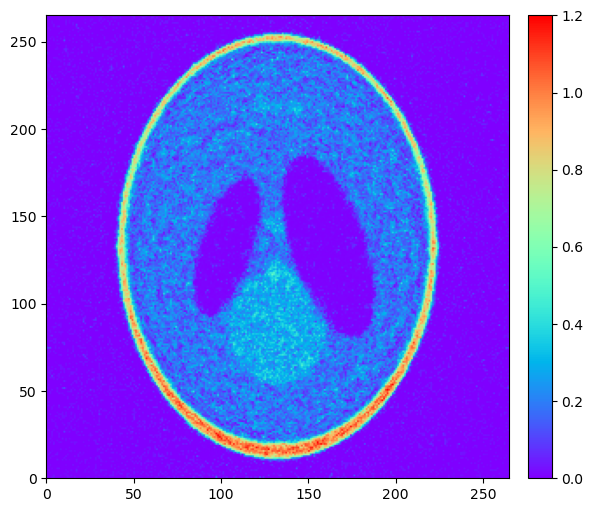

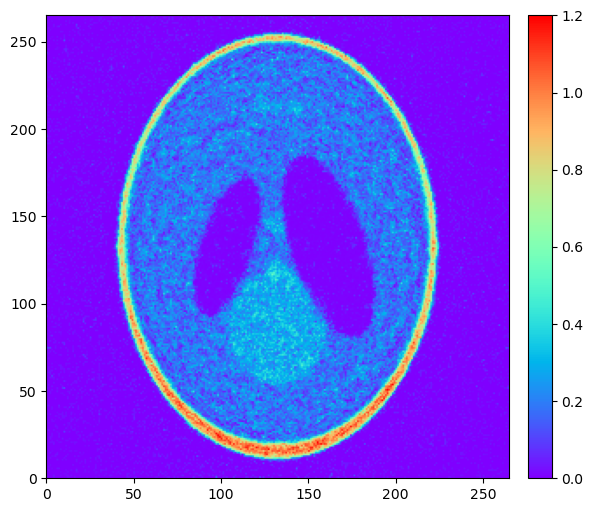

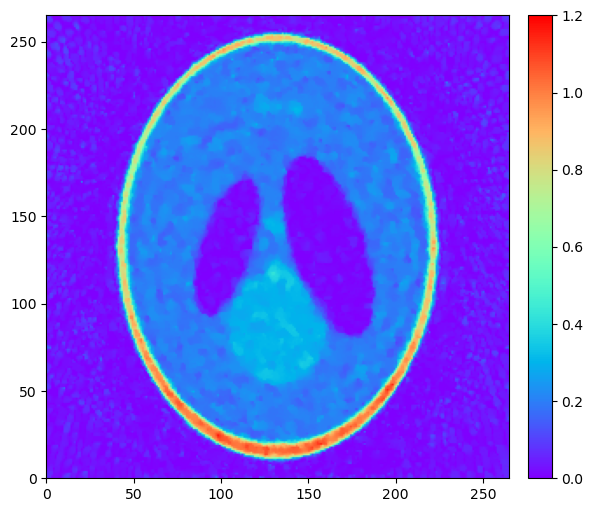

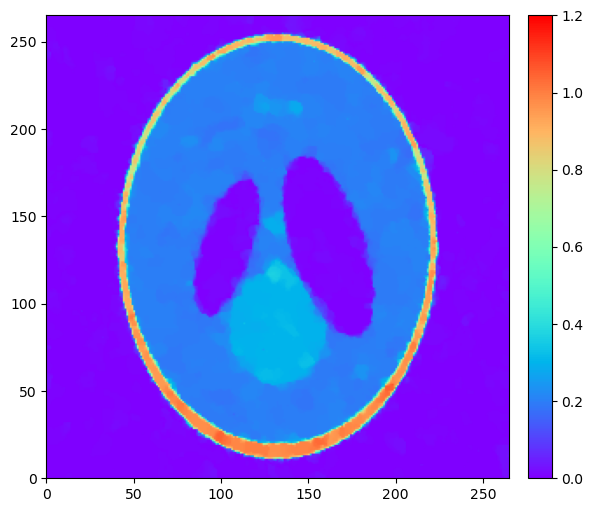

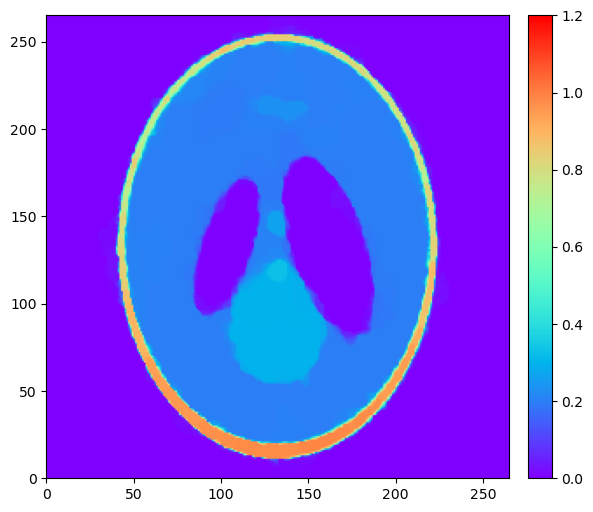

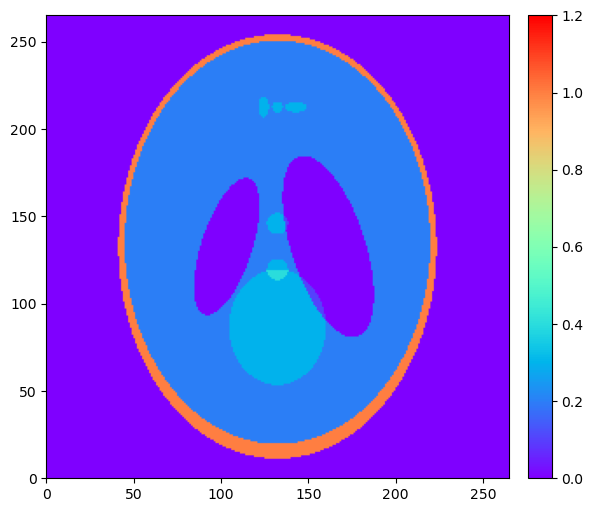

In [54]:
show2D(lasso_cgls_sol.abs(), cmap='rainbow', axis_labels=('', ''), size=(10,10), fix_range=(0, 1.2))
show2D(lasso_cg.abs(), cmap = 'rainbow', axis_labels=('', ''), size=(10,10), fix_range=(0,1.2))
show2D(tv_cgls_sol.abs(), cmap='rainbow', axis_labels=('', ''), size=(10,10), fix_range=(0, 1.2))
show2D(tv_cg.abs(), cmap = 'rainbow', axis_labels=('', ''), size=(10,10), fix_range=(0,1.2))
show2D(fista_sol.abs(), cmap = 'rainbow', axis_labels=('', ''), size=(10,10), fix_range=(0,1.2))
show2D(phantom, size=(10,10), fix_range=(0,1.2), axis_labels=( '',''), cmap='rainbow')

c:\Users\femke\anaconda3\envs\cil_demos_cpu\Lib\site-packages\cil\framework\data_container.py:112: UserWarning: Over-riding geometry.dtype with data.dtype
  warnings.warn("Over-riding geometry.dtype with data.dtype", UserWarning)


outer iteration: 1
cg converged in 1 iterations
outer iteration: 2
cg converged in 46 iterations
outer iteration: 3
cg converged in 84 iterations
outer iteration: 4
outer iteration: 5
outer iteration: 6
outer iteration: 7
outer iteration: 8
outer iteration: 9
outer iteration: 10
time for tv cg: 59.083094358444214


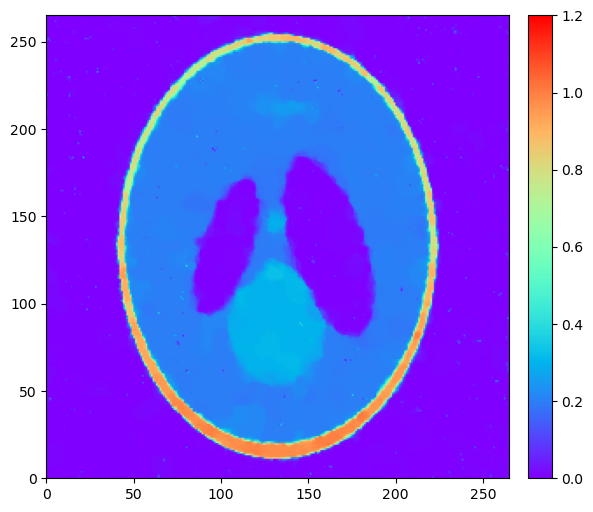

In [37]:
sino_noisy = add_poss_noise(background_counts=15000, n_angles=50, n_pixels=265)

tstart = time.time()
tv_cg, tv_cg_error, tv_cg_convarr, tv_cg_inneriterations = tv_solver_normal(initial = ig.allocate(0), 
                                                                            inner_iter = 100, 
                                                                            outer_iter = 10, 
                                                                            R = R, 
                                                                            sino = sino_noisy, 
                                                                            alpha = 8e-7, 
                                                                            er = None, 
                                                                            pre = "False", 
                                                                            cg_tol = 2e-2, 
                                                                            vox_size = None, 
                                                                            exact = phantom)
tend = time.time()
print("time for tv cg:", tend - tstart)

show2D(tv_cg.abs(), cmap = 'rainbow', fix_range=(0,1.2), size=(10,10), axis_labels=('', ''))

## Chapter 5

In [55]:
R, sino, ig, ag, phantom = get_A(n_angles=50, n_pixels=265)
sino_noisy = add_poss_noise(background_counts=20000, n_angles=50, n_pixels=265)
norm = L2NormSquared()

time_cg = []
time_pcg = []
time_fista = []

time_cg.append(0)
time_pcg.append(0)
time_fista.append(0)

error_cg = []
error_pcg = []
error_fista = []

initial_error = norm(phantom)
error_cg.append(initial_error)
error_pcg.append(initial_error)
error_fista.append(initial_error)

f1 = LeastSquares(R, sino_noisy, (1/2))
TV = FGP_TV(alpha=3e-4, nonnegativity=True, device='cpu')
fista_TV = FISTA(initial=ig.allocate(0), f=f1, g=TV, update_objective_interval=10)


for i in [1,2, 3, 4, 5, 6, 7, 8, 9, 10]:
    tstart = time.time()
    tv_cg_pre, tv_cg_error_pre, tv_cg_convarr_pre, tv_cg_inneriterations_pre = tv_solver_normal(initial = ig.allocate(0), 
                                                                            inner_iter = 100, 
                                                                            outer_iter = i, 
                                                                            R = R, 
                                                                            sino = sino_noisy, 
                                                                            alpha = 5e-7, 
                                                                            er = None, 
                                                                            pre = "True", 
                                                                            cg_tol = 2e-1, 
                                                                            vox_size = 1/265,
                                                                            exact = phantom)
    tend = time.time()
    time_pcg.append(tend - tstart)
    error_pcg.append(norm(phantom - tv_cg_pre))

    tstart = time.time()
    tv_cg, tv_cg_error, tv_cg_convarr, tv_cg_inneriterations = tv_solver_normal(initial = ig.allocate(0), 
                                                                            inner_iter = 100, 
                                                                            outer_iter = i, 
                                                                            R = R, 
                                                                            sino = sino_noisy, 
                                                                            alpha = 5e-7, 
                                                                            er = None, 
                                                                            pre = "False", 
                                                                            cg_tol = 2e-1, 
                                                                            vox_size = None, 
                                                                            exact = phantom)
    tend = time.time()
    time_cg.append(tend - tstart)
    error_cg.append(norm(phantom - tv_cg))

    t1 = time.time()
    fista_TV.run(i*10)
    t2 = time.time()
    time_fista.append(tend - tstart)

    solution = fista_TV.solution
    error_fista.append(norm(phantom - solution))

outer iteration: 1
cg converged in 1 iterations
outer iteration: 1
cg converged in 1 iterations


  0%|          | 0/10 [00:00<?, ?it/s]

outer iteration: 1
cg converged in 1 iterations
outer iteration: 2
cg converged in 4 iterations
outer iteration: 1
cg converged in 1 iterations
outer iteration: 2
cg converged in 19 iterations


 37%|###6      | 11/30 [00:00<?, ?it/s]

outer iteration: 1
cg converged in 1 iterations
outer iteration: 2
cg converged in 4 iterations
outer iteration: 3
cg converged in 5 iterations
outer iteration: 1
cg converged in 1 iterations
outer iteration: 2
cg converged in 19 iterations
outer iteration: 3
cg converged in 34 iterations


...

 78%|#######8  | 281/360 [00:00<?, ?it/s]

outer iteration: 1
cg converged in 1 iterations
outer iteration: 2
cg converged in 4 iterations
outer iteration: 3
cg converged in 5 iterations
outer iteration: 4
cg converged in 6 iterations
outer iteration: 5
cg converged in 5 iterations
outer iteration: 6
cg converged in 8 iterations
outer iteration: 7
cg converged in 4 iterations
outer iteration: 8
cg converged in 6 iterations
outer iteration: 9
cg converged in 2 iterations
outer iteration: 1
cg converged in 1 iterations
outer iteration: 2
cg converged in 19 iterations
outer iteration: 3
cg converged in 34 iterations
outer iteration: 4
cg converged in 58 iterations
outer iteration: 5
cg converged in 68 iterations
outer iteration: 6
cg converged in 66 iterations
outer iteration: 7
cg converged in 67 iterations
outer iteration: 8
cg converged in 76 iterations
outer iteration: 9
cg converged in 36 iterations


 80%|########  | 361/450 [00:00<?, ?it/s]

outer iteration: 1
cg converged in 1 iterations
outer iteration: 2
cg converged in 4 iterations
outer iteration: 3
cg converged in 5 iterations
outer iteration: 4
cg converged in 6 iterations
outer iteration: 5
cg converged in 5 iterations
outer iteration: 6
cg converged in 8 iterations
outer iteration: 7
cg converged in 4 iterations
outer iteration: 8
cg converged in 7 iterations
outer iteration: 9
cg converged in 2 iterations
outer iteration: 10
cg converged in 2 iterations
outer iteration: 1
cg converged in 1 iterations
outer iteration: 2
cg converged in 19 iterations
outer iteration: 3
cg converged in 34 iterations
outer iteration: 4
cg converged in 58 iterations
outer iteration: 5
cg converged in 68 iterations
outer iteration: 6
cg converged in 66 iterations
outer iteration: 7
cg converged in 67 iterations
outer iteration: 8
cg converged in 76 iterations
outer iteration: 9
cg converged in 36 iterations
outer iteration: 10
cg converged in 22 iterations


 82%|########2 | 451/550 [00:00<?, ?it/s]

<>:9: SyntaxWarning: invalid escape sequence '\|'
<>:9: SyntaxWarning: invalid escape sequence '\|'
C:\Users\femke\AppData\Local\Temp\ipykernel_18532\51666884.py:9: SyntaxWarning: invalid escape sequence '\|'
  plt.ylabel('$\|u_{exact} - u\|_2^2$')


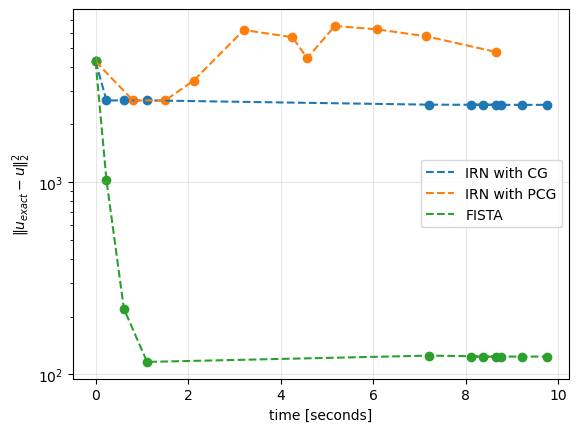

In [50]:
plt.figure()
plt.semilogy(time_cg, error_cg, label='IRN with CG', linestyle='--')
plt.scatter(time_cg, error_cg)
plt.semilogy(time_pcg, error_pcg, label='IRN with PCG', linestyle='--')
plt.scatter(time_pcg, error_pcg)
plt.semilogy(time_fista, error_fista, label='FISTA', linestyle='--')
plt.scatter(time_fista, error_fista)
plt.xlabel('time [seconds]')
plt.ylabel('$\|u_{exact} - u\|_2^2$')
plt.legend()
plt.grid(alpha = 0.3)
plt.show()